## Project Introduction

This Colab project implements a binary drug-drug interaction (DDI) prediction exercise using public BioSNAP Decagon data. It is educational only: predictions cannot establish clinical safety, causality, or prescribing guidance.

## Paper Overview

Based on Lu et al. (2026), Machine learning models for drug-drug interaction prediction: from computational discovery to clinical application. The review describes public data, handcrafted-feature classifiers, deep learning, and graph neural networks, and cautions about imbalance, generalization, interpretability, and clinical validation.

## Objective

We simplify the reviewed approaches to compare an interpretable Random Forest using engineered network features with a graph-convolutional link predictor. Multiple recorded side-effect records for one pair are collapsed into one positive edge. Random unobserved pairs are provisional negatives, not proven non-interactions.

## Environment Setup

What: install imports and set seeds. Why: a reproducible experiment. Change SEED to test repeatability; change USE_GPU to False for CPU. Expected: device and version output.

In [1]:
!pip -q install pandas numpy scikit-learn seaborn matplotlib torch
import random, tarfile, urllib.request
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
import torch, torch.nn as nn, torch.nn.functional as F
SEED=42
USE_GPU=True
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
device=torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")
print("Device:",device,"torch:",torch.__version__)

Device: cuda torch: 2.11.0+cu128


## Dataset

What: automatically download the public BioSNAP Decagon Combo archive from Stanford SNAP. Why: it is freely accessible and labeled. Change MAX_POSITIVE_PAIRS for runtime and MAX_DRUGS for graph size; larger values improve coverage but slow the dense graph model. Expected: CSV columns and sample.

In [8]:
URL="https://snap.stanford.edu/decagon/bio-decagon-combo.tar.gz"
D=Path("ddi_data"); D.mkdir(exist_ok=True); arc=D/"bio-decagon-combo.tar.gz"
MAX_POSITIVE_PAIRS=12000
MAX_DRUGS=900
if not arc.exists(): urllib.request.urlretrieve(URL,arc)
with tarfile.open(arc,"r:gz") as t:
 m=next(x for x in t.getmembers() if x.name.endswith(".csv") and "combo" in x.name and not Path(x.name).name.startswith("._"))
 csv=D/m.name
 if not csv.exists(): t.extract(m,D)
raw=pd.read_csv(csv, encoding='latin1')
print(raw.shape,raw.columns.tolist()); display(raw.head())

/tmp/ipykernel_3234/1379006958.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  if not csv.exists(): t.extract(m,D)


(4649441, 4) ['STITCH 1', 'STITCH 2', 'Polypharmacy Side Effect', 'Side Effect Name']


,STITCH 1,STITCH 2,Polypharmacy Side Effect,Side Effect Name
0,CID000002173,CID000003345,C0151714,hypermagnesemia
1,CID000002173,CID000003345,C0035344,retinopathy of prematurity
2,CID000002173,CID000003345,C0004144,atelectasis
3,CID000002173,CID000003345,C0002063,alkalosis
4,CID000002173,CID000003345,C0004604,Back Ache


## EDA

What: make unique undirected drug pairs and inspect degree distribution. Why: repeated side-effect records must not overweight pairs. If columns differ, change a,b after inspection. Expected: statistics and histogram.

,stat,value
0,raw rows,4.649441e+06
1,positive pairs,1.200000e+04
2,drugs,6.340000e+02
3,mean degree,3.785489e+01


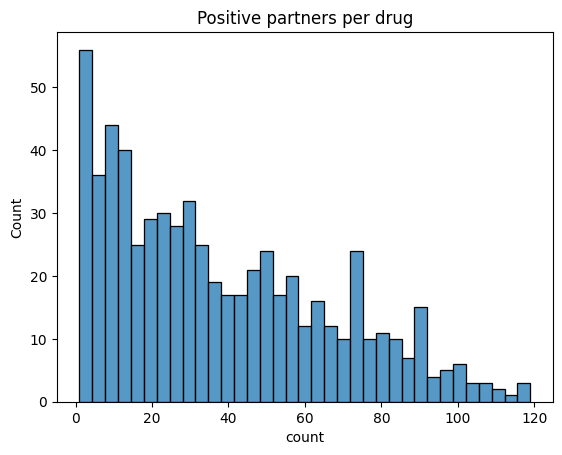

In [9]:
a,b=raw.columns[:2]
p=raw[[a,b]].astype(str); p.columns=["drug_a","drug_b"]
p["k"]=p.apply(lambda r:"|".join(sorted((r.drug_a,r.drug_b))),axis=1)
pos=p.drop_duplicates("k")[["drug_a","drug_b"]]
top=pd.concat([pos.drug_a,pos.drug_b]).value_counts().head(MAX_DRUGS).index
pos=pos[pos.drug_a.isin(top)&pos.drug_b.isin(top)].head(MAX_POSITIVE_PAIRS)
drugs=sorted(set(pos.drug_a)|set(pos.drug_b)); ix={d:i for i,d in enumerate(drugs)}
P={tuple(sorted((ix[x],ix[y]))) for x,y in pos.itertuples(index=False)}
deg=pd.concat([pos.drug_a,pos.drug_b]).value_counts()
display(pd.DataFrame({"stat":["raw rows","positive pairs","drugs","mean degree"],"value":[len(raw),len(P),len(drugs),deg.mean()]}))
sns.histplot(deg,bins=35); plt.title("Positive partners per drug"); plt.show()

## Preprocessing

What: create a balanced binary dataset using random non-recorded pairs. Why: a classifier needs negatives. Change NEGATIVE_RATIO; increasing it creates a harder, more imbalanced setting. Expected: class distribution.

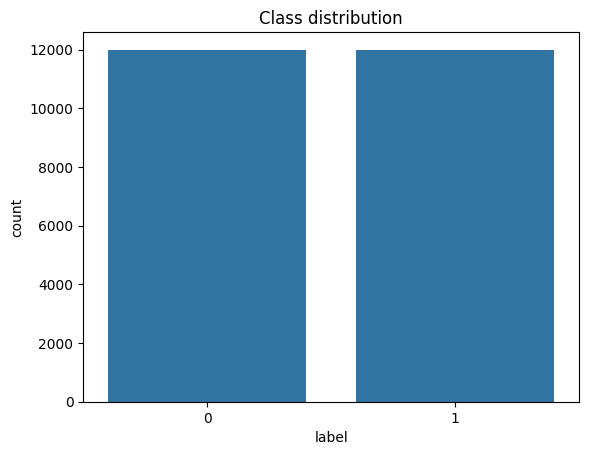

In [10]:
NEGATIVE_RATIO=1.0
N=set()
while len(N)<int(len(P)*NEGATIVE_RATIO):
 u,v=sorted(np.random.choice(len(drugs),2,replace=False))
 if (u,v) not in P: N.add((u,v))
posdf=pd.DataFrame(list(P),columns=["u","v"]); posdf["label"]=1
negdf=pd.DataFrame(list(N),columns=["u","v"]); negdf["label"]=0
data=pd.concat([posdf,negdf]).sample(frac=1,random_state=SEED).reset_index(drop=True)
sns.countplot(data=data,x="label"); plt.title("Class distribution"); plt.show()

## Feature Engineering and Split

What: make stratified train/validation/test splits and training-only graph features. Why: prevents direct test-edge leakage. Change TEST_SIZE and VAL_SIZE; larger test is more stable but leaves less training data. Features are degree, common neighbors, Jaccard similarity, and preferential attachment. Expected: split sizes and feature plots.

train 16800 0.5
validation 2400 0.5
test 4800 0.5


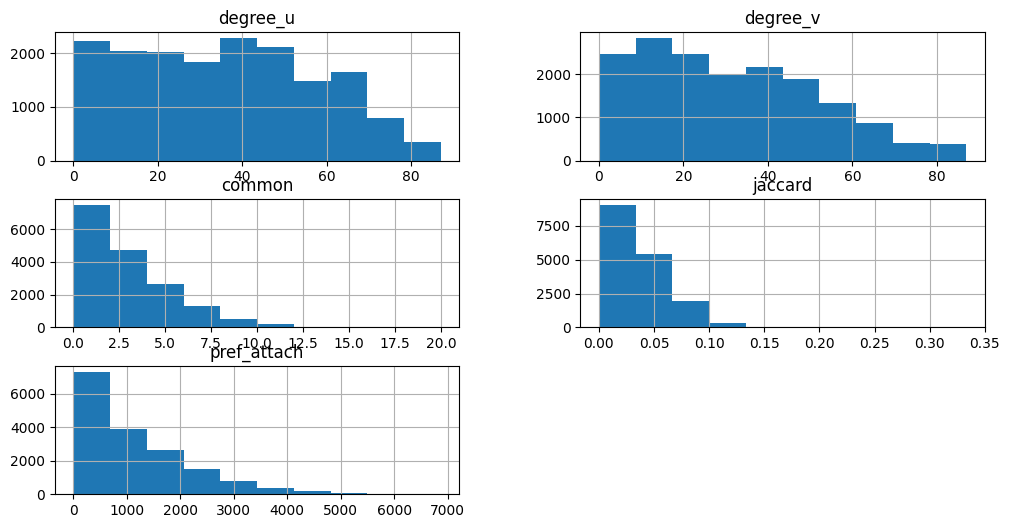

In [11]:
TEST_SIZE=.20; VAL_SIZE=.10
tv,te=train_test_split(data,test_size=TEST_SIZE,stratify=data.label,random_state=SEED)
tr,va=train_test_split(tv,test_size=VAL_SIZE/(1-TEST_SIZE),stratify=tv.label,random_state=SEED)
for z,d in [("train",tr),("validation",va),("test",te)]: print(z,len(d),d.label.mean())
n=len(drugs); A0=np.zeros((n,n),dtype=np.float32)
e=tr[tr.label==1][["u","v"]].values; A0[e[:,0],e[:,1]]=1; A0[e[:,1],e[:,0]]=1
degree=A0.sum(1)
def feat(d):
 out=[]
 for u,v in d[["u","v"]].itertuples(index=False):
  common=A0[u]@A0[v]; union=degree[u]+degree[v]-common
  out.append([degree[u],degree[v],common,common/(union+1e-8),degree[u]*degree[v]])
 return np.asarray(out,dtype=np.float32)
Xtr,Xva,Xte=feat(tr),feat(va),feat(te); ytr,yva,yte=tr.label.values,va.label.values,te.label.values
pd.DataFrame(Xtr,columns=["degree_u","degree_v","common","jaccard","pref_attach"]).hist(figsize=(12,6)); plt.show()

## Model 1: Random Forest

What: train traditional ML on handcrafted features. Why: practical nonlinear baseline from the paper's classifier family. Change N_ESTIMATORS, MAX_DEPTH, MIN_LEAF, THRESHOLD. More trees stabilize but slow; deeper trees can overfit; higher threshold yields fewer alerts and often higher precision. Expected: validation AUC and importances.

RF validation: 0.8144750000000001 0.7651588683309654


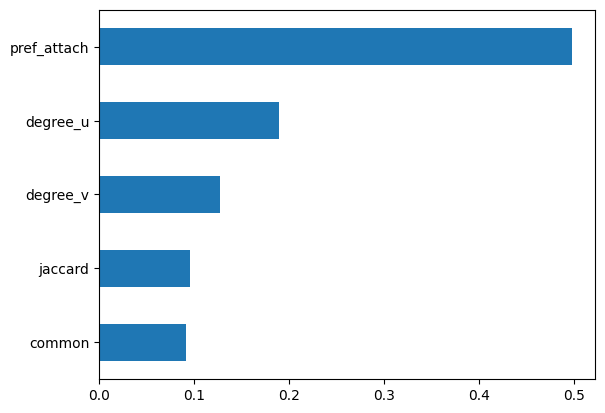

In [12]:
N_ESTIMATORS=300; MAX_DEPTH=12; MIN_LEAF=2; THRESHOLD=.50
rf=RandomForestClassifier(n_estimators=N_ESTIMATORS,max_depth=MAX_DEPTH,min_samples_leaf=MIN_LEAF,class_weight="balanced",random_state=SEED,n_jobs=-1)
rf.fit(Xtr,ytr)
print("RF validation:",roc_auc_score(yva,rf.predict_proba(Xva)[:,1]),average_precision_score(yva,rf.predict_proba(Xva)[:,1]))
pd.Series(rf.feature_importances_,index=["degree_u","degree_v","common","jaccard","pref_attach"]).sort_values().plot.barh(); plt.show()

## Model 2: Graph-Based Deep Learning

What: train a two-layer GCN autoencoder on training graph edges; a dot product decodes pair probability. Why: a realistic dependency-light graph representation model. Change HIDDEN, EMBED, DROPOUT, LR, EPOCHS, PATIENCE. Bigger networks have more capacity but can overfit; a high learning rate can destabilize; more dropout regularizes. Expected: loss progress.

In [13]:
def normalize(a):
 a=a+np.eye(len(a),dtype=np.float32); d=np.diag(1/np.sqrt(a.sum(1)+1e-8)); return d@a@d
A=torch.tensor(normalize(A0),dtype=torch.float32,device=device); I=torch.eye(n,device=device)
class GCN(nn.Module):
 def __init__(self):
  super().__init__(); self.l1=nn.Linear(n,HIDDEN,bias=False); self.l2=nn.Linear(HIDDEN,EMBED,bias=False)
 def forward(self,p):
  z=A@self.l2(F.dropout(F.relu(A@self.l1(I)),p=DROPOUT,training=self.training))
  return (z[p[:,0]]*z[p[:,1]]).sum(1)
HIDDEN=64; EMBED=32; DROPOUT=.15; LR=.01; EPOCHS=150; PATIENCE=20
gcn=GCN().to(device); opt=torch.optim.Adam(gcn.parameters(),lr=LR,weight_decay=1e-4); lossfn=nn.BCEWithLogitsLoss()
ptr=torch.tensor(tr[["u","v"]].values,device=device); pva=torch.tensor(va[["u","v"]].values,device=device)
ltr=torch.tensor(ytr,dtype=torch.float32,device=device); lva=torch.tensor(yva,dtype=torch.float32,device=device)
hist={"train":[],"val":[]}; best=1e9; wait=0
for epoch in range(EPOCHS):
 gcn.train(); opt.zero_grad(); loss=lossfn(gcn(ptr),ltr); loss.backward(); opt.step()
 gcn.eval()
 with torch.no_grad(): vl=lossfn(gcn(pva),lva).item()
 hist["train"].append(loss.item()); hist["val"].append(vl)
 if vl<best: best=vl; wait=0; state={k:v.detach().cpu().clone() for k,v in gcn.state_dict().items()}
 else: wait+=1
 if wait>=PATIENCE: break
print("best validation loss",best,"epochs",epoch+1); gcn.load_state_dict(state)

best validation loss 0.6931448578834534 epochs 21


<All keys matched successfully>

## Evaluation and Visualizations

What: calculate Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, confusion matrices, ROC/PR curves, comparison chart, and training curves on untouched test pairs. Why: each shows a different aspect of performance. Experiment with THRESHOLD, but select it on validation data in real work. Expected: table and charts.

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.739,0.712,0.802,0.754,0.792,0.731
1,GCN,0.500,0.500,1.000,0.667,0.751,0.669


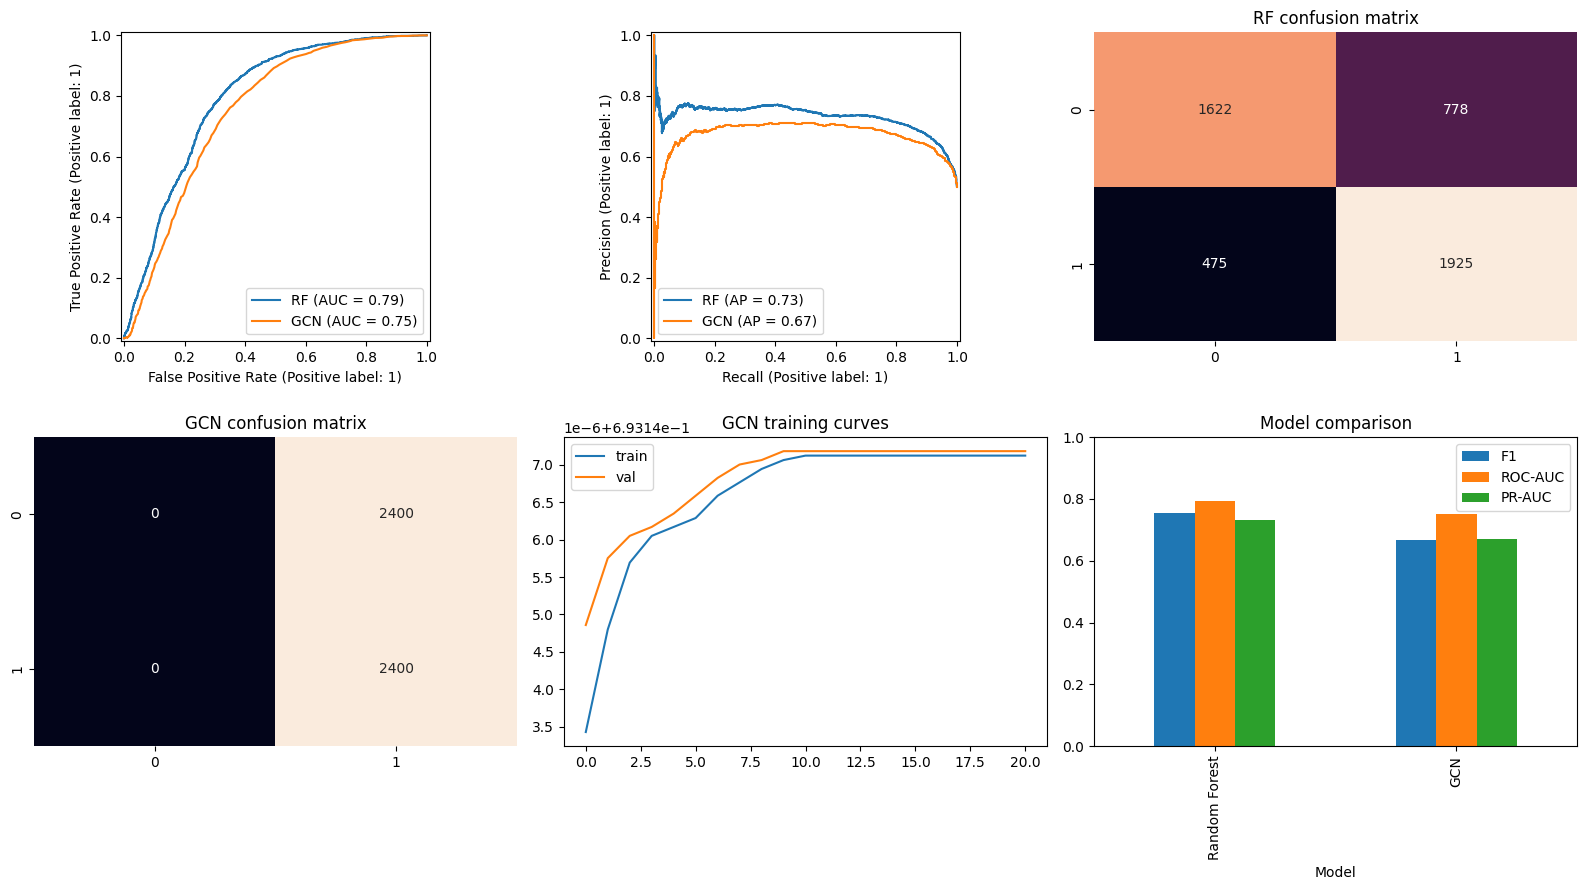

In [14]:
prf=rf.predict_proba(Xte)[:,1]
gcn.eval(); pte=torch.tensor(te[["u","v"]].values,device=device)
with torch.no_grad(): pg=torch.sigmoid(gcn(pte)).cpu().numpy()
def row(name,p):
 q=(p>=THRESHOLD).astype(int)
 return [name,accuracy_score(yte,q),precision_score(yte,q),recall_score(yte,q),f1_score(yte,q),roc_auc_score(yte,p),average_precision_score(yte,p)]
res=pd.DataFrame([row("Random Forest",prf),row("GCN",pg)],columns=["Model","Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC"])
display(res.style.format({x:"{:.3f}" for x in res.columns[1:]}))
fig,ax=plt.subplots(2,3,figsize=(16,9)); ax=ax.ravel()
for p,name in [(prf,"RF"),(pg,"GCN")]:
 RocCurveDisplay.from_predictions(yte,p,name=name,ax=ax[0]); PrecisionRecallDisplay.from_predictions(yte,p,name=name,ax=ax[1])
for a,p,name in zip(ax[2:4],[prf,pg],["RF","GCN"]):
 sns.heatmap(confusion_matrix(yte,p>=THRESHOLD),annot=True,fmt="d",cbar=False,ax=a); a.set_title(name+" confusion matrix")
pd.DataFrame(hist).plot(ax=ax[4]); ax[4].set_title("GCN training curves")
res.set_index("Model")[["F1","ROC-AUC","PR-AUC"]].plot.bar(ax=ax[5],ylim=(0,1)); ax[5].set_title("Model comparison")
plt.tight_layout(); plt.show()

## Example Predictions

What: rank held-out pairs by model score. Why: models prioritize candidates for review. Change MODEL and N_EXAMPLES. Expected: table. A zero label means unobserved/sampled negative, not safe.

In [15]:
MODEL="gcn"; N_EXAMPLES=10
p=pg if MODEL=="gcn" else prf
out=te.copy(); out["drug_1"]=out.u.map(lambda z:drugs[z]); out["drug_2"]=out.v.map(lambda z:drugs[z]); out["probability"]=p
display(out[["drug_1","drug_2","label","probability"]].sort_values("probability",ascending=False).head(N_EXAMPLES))

,drug_1,drug_2,label,probability
10881,CID000004889,CID000039860,0,0.500062
8398,CID000002551,CID000004140,0,0.500060
2596,CID000002370,CID000002806,0,0.500059
645,CID000000853,CID000002370,1,0.500057
22572,CID000039860,CID000125889,1,0.500053
14418,CID000002244,CID000002370,0,0.500051
15738,CID000039860,CID000060831,0,0.500051
1884,CID000005245,CID000039860,0,0.500048
14868,CID000002370,CID000005038,0,0.500046
6120,CID000002675,CID000004594,1,0.500045


## Limitations, How to Improve, Conclusion

Limitations: incomplete labels, unknown negatives, optimistic random split, topology-only features, and no external clinical validation. Improve with chemical/target/pathway data, relation-aware GNNs, cold-start and temporal splits, calibration, explainability, repeated seeds, and independent experimental/clinical validation. Conclusion: this is a reproducible prioritization demo, not a clinical system.

## Experiments You Can Try

Change Random Forest hyperparameters; alter topology or add public chemical features; change train/test ratio; change HIDDEN, EMBED, DROPOUT, LR, EPOCHS, and PATIENCE; refactor full-batch pair loss for minibatches; vary THRESHOLD; and gradually increase MAX_POSITIVE_PAIRS/MAX_DRUGS. Increasing model size/epochs may improve fit but increases runtime and overfitting risk.